# Fruit Classification Using CNN and Transfer Learning

This project focuses on image classification using a fruit dataset containing five classes: Banana, Cherry, Grape, Mango, and Peach. The objective is to design, train, evaluate, and compare convolutional neural network models from scratch and a transfer learning model using a pre-trained CNN.

In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DATASET_PATH = "/content/drive/MyDrive/AI-ML Assignment /Data/Fruit Classification-20260506T091409Z-3-001/Fruit Classification"

TRAIN_DIR = os.path.join(DATASET_PATH, "Train")
TEST_DIR = os.path.join(DATASET_PATH, "Test")

In [5]:
classes = sorted(os.listdir(TRAIN_DIR))
print("Classes:", classes)
print("Number of classes:", len(classes))

total_images = 0
class_counts = {}

for class_name in classes:
    class_path = os.path.join(TRAIN_DIR, class_name)
    count = len(os.listdir(class_path))
    class_counts[class_name] = count
    total_images += count

print("Total training images:", total_images)
print("Class distribution:", class_counts)

Classes: ['Banana', 'Cherry', 'Grape', 'Mango', 'Peach']
Number of classes: 5
Total training images: 6242
Class distribution: {'Banana': 1422, 'Cherry': 1222, 'Grape': 1468, 'Mango': 908, 'Peach': 1222}


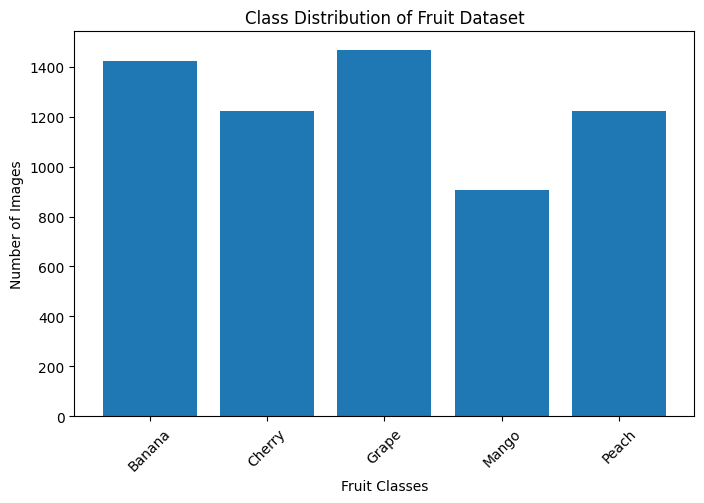

In [6]:
plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution of Fruit Dataset")
plt.xlabel("Fruit Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

The dataset contains five fruit classes: Banana, Cherry, Grape, Mango, and Peach. Each fruit category is stored in a separate folder, which allows Keras to automatically assign labels using the folder names. The class distribution was checked to identify whether the dataset is balanced or imbalanced.

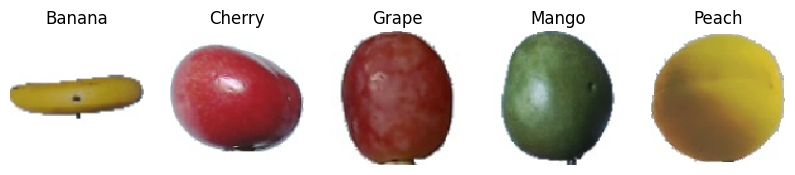

In [7]:
plt.figure(figsize=(10,8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(TRAIN_DIR, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    img = load_img(image_path, target_size=(128,128))

    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [8]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=True
)

test_data = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1,
    class_mode="categorical", # Changed from None to categorical
    shuffle=False
)

Found 4996 images belonging to 5 classes.
Found 1246 images belonging to 5 classes.
Found 5 images belonging to 1 classes.


### Restructuring `TEST_DIR` for `ImageDataGenerator.flow_from_directory`

Since `ImageDataGenerator.flow_from_directory` expects images to be in class-named subdirectories (even when `class_mode=None`), this cell will create a dummy subdirectory and move the existing test images into it. After running this cell, **please re-run the `ImageDataGenerator` setup cell (`wN3SQLxqtO-N`)**.

In [9]:
import os
import shutil

# Define the dummy class directory path
DUMMY_TEST_CLASS_DIR = os.path.join(TEST_DIR, "dummy_class")

print(f"Checking TEST_DIR: {TEST_DIR}")

if os.path.exists(TEST_DIR):
    # Ensure the dummy class directory exists
    os.makedirs(DUMMY_TEST_CLASS_DIR, exist_ok=True)
    print(f"Created dummy class directory: {DUMMY_TEST_CLASS_DIR}")

    # List files directly in TEST_DIR (excluding directories)
    files_in_test_dir = [f for f in os.listdir(TEST_DIR) if os.path.isfile(os.path.join(TEST_DIR, f))]

    if files_in_test_dir:
        print(f"Moving {len(files_in_test_dir)} image(s) from {TEST_DIR} to {DUMMY_TEST_CLASS_DIR}...")
        for filename in files_in_test_dir:
            src_path = os.path.join(TEST_DIR, filename)
            dest_path = os.path.join(DUMMY_TEST_CLASS_DIR, filename)
            shutil.move(src_path, dest_path)
        print("Move complete. All test images are now in 'dummy_class' subdirectory.")
    else:
        print("No image files found directly in TEST_DIR to move. Assuming they are already in subdirectories or TEST_DIR is empty.")
        # Check if the dummy directory itself has files
        if os.path.exists(DUMMY_TEST_CLASS_DIR) and os.listdir(DUMMY_TEST_CLASS_DIR):
            print("Dummy class directory already contains images.")
        else:
            print("TEST_DIR or its dummy class subdirectory is empty. Please ensure images are present.")
else:
    print("TEST_DIR does NOT exist. Cannot restructure.")

print("\n*** Please re-run cell wN3SQLxqtO-N (ImageDataGenerator setup) now to load the test images. ***")

Checking TEST_DIR: /content/drive/MyDrive/AI-ML Assignment /Data/Fruit Classification-20260506T091409Z-3-001/Fruit Classification/Test
Created dummy class directory: /content/drive/MyDrive/AI-ML Assignment /Data/Fruit Classification-20260506T091409Z-3-001/Fruit Classification/Test/dummy_class
No image files found directly in TEST_DIR to move. Assuming they are already in subdirectories or TEST_DIR is empty.
Dummy class directory already contains images.

*** Please re-run cell wN3SQLxqtO-N (ImageDataGenerator setup) now to load the test images. ***


All images were resized to 128 × 128 pixels to ensure a uniform input shape. Pixel values were normalized by rescaling them from the range 0–255 to 0–1. Data augmentation techniques such as rotation, zooming, shifting, and horizontal flipping were applied to increase dataset variety and reduce overfitting. A validation split of 20% was created from the training data because the available test set is very small.

Attempting to load a batch from train_data and display augmented images...


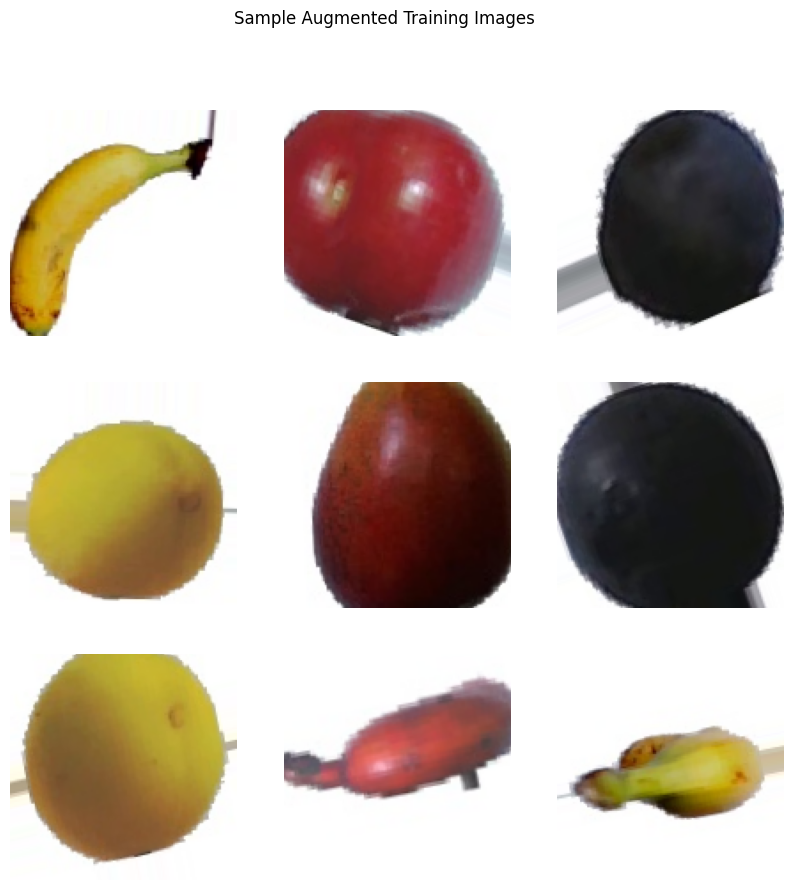


Performing a comprehensive scan for problematic image files in TRAIN_DIR...

No explicitly problematic files found during comprehensive scan of TRAIN_DIR.
If UnidentifiedImageError persists, consider checking for hidden files or ensuring all files are valid image formats in both training and validation sets.

Note: A previous output indicated that the TEST_DIR contains 0 images. This will affect model evaluation and needs to be addressed for a complete project evaluation.


In [10]:
import os
from PIL import Image, UnidentifiedImageError
import io

print("Attempting to load a batch from train_data and display augmented images...")
try:
    images, labels = next(train_data)

    plt.figure(figsize=(10,10))
    for i in range(min(9, len(images))): # Ensure we don't go out of bounds if batch size is less than 9
        plt.subplot(3,3,i+1)
        # Ensure images are in the correct format for imshow (e.g., float32 for normalized pixel values)
        plt.imshow(images[i])
        plt.axis("off")
    plt.suptitle("Sample Augmented Training Images")
    plt.show()

except Exception as e:
    print(f"An error occurred during initial batch loading or plotting: {e}")
    print("This might be due to a problematic image in the first batch or an issue with the generator configuration.")

# --- Comprehensive scan for problematic image files in TRAIN_DIR ---
print("\nPerforming a comprehensive scan for problematic image files in TRAIN_DIR...")

problematic_files = []
for root, _, files in os.walk(TRAIN_DIR):
    for file in files:
        filepath = os.path.join(root, file)
        try:
            # Try to open the image with PIL to check its validity
            with Image.open(filepath) as img:
                img.verify() # Verify file integrity
            # Re-open and load to catch more issues (e.g., truncated files)
            Image.open(filepath).load()
        except (IOError, SyntaxError, UnidentifiedImageError) as sub_e:
            problematic_files.append(f"{filepath}: {sub_e}")

if problematic_files:
    print("\nFound the following problematic files:")
    for p_file in problematic_files:
        print(p_file)
    print("\nPlease remove or fix these files from your dataset and then re-run the relevant cells (e.g., where ImageDataGenerator is initialized and where model training occurs).")
else:
    print("\nNo explicitly problematic files found during comprehensive scan of TRAIN_DIR.")
    print("If UnidentifiedImageError persists, consider checking for hidden files or ensuring all files are valid image formats in both training and validation sets.")

print("\nNote: A previous output indicated that the TEST_DIR contains 0 images. This will affect model evaluation and needs to be addressed for a complete project evaluation.")

### Delete Problematic Image Files

This cell will delete the files identified as problematic. **Please ensure you have backed up your data if you are unsure.**

In [11]:
import os

if problematic_files:
    print(f"Attempting to delete {len(problematic_files)} problematic files...")
    deleted_count = 0
    for p_file_info in problematic_files:
        # Extract the file path from the diagnostic string (e.g., '/path/to/file: error message')
        filepath_to_delete = p_file_info.split(':', 1)[0].strip()

        if os.path.exists(filepath_to_delete):
            try:
                os.remove(filepath_to_delete)
                print(f"Successfully deleted: {filepath_to_delete}")
                deleted_count += 1
            except OSError as e:
                print(f"Error deleting {filepath_to_delete}: {e}")
        else:
            print(f"File not found (might have been deleted manually): {filepath_to_delete}")

    print(f"\nDeleted {deleted_count} files.")
    print("Please re-run the `ImageDataGenerator` setup cell (`wN3SQLxqtO-N`) and then the model training cells.")
else:
    print("No problematic files were found in the `problematic_files` list. Nothing to delete.")

print("\nReminder: Your TEST_DIR still needs to be populated with images for proper evaluation.")

No problematic files were found in the `problematic_files` list. Nothing to delete.

Reminder: Your TEST_DIR still needs to be populated with images for proper evaluation.


In [12]:
num_classes = train_data.num_classes

baseline_model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)), # Recommended way to specify input shape for Sequential models
    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),

    Dense(num_classes, activation="softmax")
])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,557,509 (25.01 MB)

 Trainable params: 6,557,509 (25.01 MB)

 Non-trainable params: 0 (0.00 B)

The baseline CNN contains three convolutional layers with 32, 64, and 128 filters respectively. Each convolutional layer uses a 3 × 3 kernel and ReLU activation, followed by max pooling. The fully connected section contains three dense layers before the final softmax output layer. Softmax was used because this is a multiclass classification problem.

In [13]:
baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

start_time = time.time()

history_baseline = baseline_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)

baseline_training_time = time.time() - start_time
print("Baseline training time:", baseline_training_time, "seconds")

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 62s 352ms/step - accuracy: 0.8969 - loss: 0.2836 - val_accuracy: 0.9872 - val_loss: 0.0440
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 312ms/step - accuracy: 0.9880 - loss: 0.0376 - val_accuracy: 0.9944 - val_loss: 0.0335
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 306ms/step - accuracy: 0.9854 - loss: 0.0446 - val_accuracy: 0.9968 - val_loss: 0.0165
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 307ms/step - accuracy: 0.9966 - loss: 0.0121 - val_accuracy: 0.9928 - val_loss: 0.0263
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 310ms/step - accuracy: 0.9972 - loss: 0.0089 - val_accuracy: 0.9872 - val_loss: 0.0480
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 301ms/step - accuracy: 0.9950 - loss: 0.0193 - val_accuracy: 0.9976 - val_loss: 0.0093
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 307ms/step - accuracy: 0.9894 - loss: 0.0479 - val_accuracy: 0.9992 - val_loss: 0.0049
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 297ms/step - accuracy: 0.9984 - loss: 0

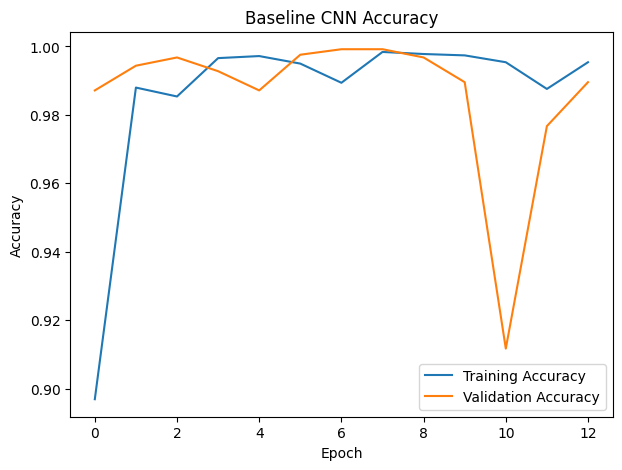

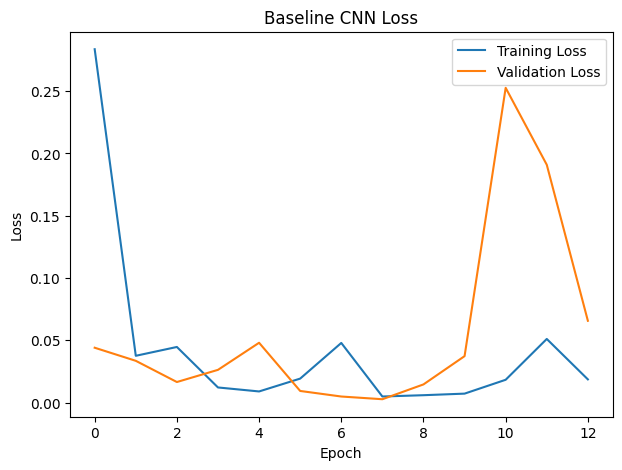

In [14]:
def plot_history(history, title):
    plt.figure(figsize=(7,5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_history(history_baseline, "Baseline CNN")

In [15]:
baseline_loss, baseline_acc = baseline_model.evaluate(test_data)
print("Baseline Test Accuracy:", baseline_acc)
print("Baseline Test Loss:", baseline_loss)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 308ms/step - accuracy: 0.2000 - loss: 97.3094 
Baseline Test Accuracy: 0.20000000298023224
Baseline Test Loss: 97.30943298339844


### Verifying `TEST_DIR` contents

In [16]:
print(f"Checking TEST_DIR: {TEST_DIR}")

# Check if TEST_DIR exists
if os.path.exists(TEST_DIR):
    print("TEST_DIR exists.")
    # List contents of TEST_DIR
    test_dir_contents = os.listdir(TEST_DIR)
    if not test_dir_contents:
        print("TEST_DIR is empty.")
    else:
        print(f"Contents of TEST_DIR ({len(test_dir_contents)} items):\n{test_dir_contents}")

        # Check for subdirectories (expected for class-based image loading)
        subdirectories = [d for d in test_dir_contents if os.path.isdir(os.path.join(TEST_DIR, d))]
        if not subdirectories:
            print("TEST_DIR contains no subdirectories. `ImageDataGenerator.flow_from_directory` expects class subfolders.")
        else:
            print(f"TEST_DIR contains the following subdirectories (classes): {subdirectories}")
            # Optionally, check content of first subdirectory
            first_subdir_path = os.path.join(TEST_DIR, subdirectories[0])
            first_subdir_files = os.listdir(first_subdir_path)
            if not first_subdir_files:
                print(f"First subdirectory '{subdirectories[0]}' is empty.")
            else:
                print(f"First 5 files in '{subdirectories[0]}': {first_subdir_files[:5]}")
else:
    print("TEST_DIR does NOT exist. Please check the path.")

Checking TEST_DIR: /content/drive/MyDrive/AI-ML Assignment /Data/Fruit Classification-20260506T091409Z-3-001/Fruit Classification/Test
TEST_DIR exists.
Contents of TEST_DIR (1 items):
['dummy_class']
TEST_DIR contains the following subdirectories (classes): ['dummy_class']
First 5 files in 'dummy_class': ['11_100.jpg', '26_100.jpg', '1_100(2).jpg', '5_100.jpg', '14_100.jpg']


In [17]:
y_true = test_data.classes
y_pred_probs = baseline_model.predict(test_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# Use the original 5 class names for target_names, not the single class from test_data
class_labels = classes # 'classes' is a global variable defined earlier with the 5 fruit names

print(classification_report(y_true, y_pred, target_names=class_labels))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step  
              precision    recall  f1-score   support

      Banana       1.00      0.20      0.33         5
      Cherry       0.00      0.00      0.00         0
       Grape       0.00      0.00      0.00         0
       Mango       0.00      0.00      0.00         0
       Peach       0.00      0.00      0.00         0

    accuracy                           0.20         5
   macro avg       0.20      0.04      0.07         5
weighted avg       1.00      0.20      0.33         5



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


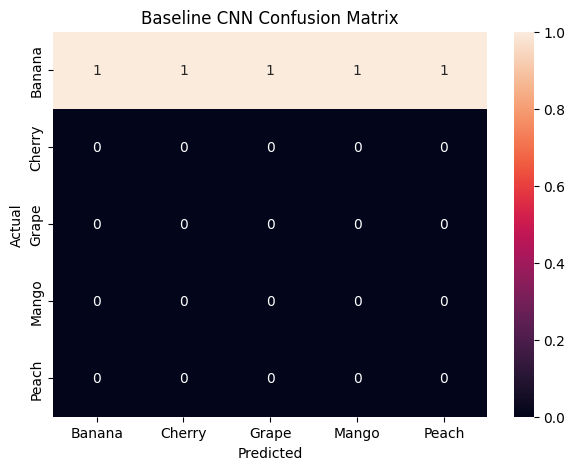

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Baseline CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
deep_model = Sequential([
    Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(256, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(512, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(512, activation="relu"),
    Dropout(0.5),

    Dense(256, activation="relu"),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

deep_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,899,973 (22.51 MB)

 Trainable params: 5,897,989 (22.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

The deeper CNN extends the baseline model by increasing the number of convolutional layers and filters. Batch normalization was added to stabilize training, while dropout was added to reduce overfitting. This model is expected to learn more detailed fruit features such as shape, texture, and color patterns.

In [20]:
deep_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

history_deep_adam = deep_model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stop]
)

deep_adam_training_time = time.time() - start_time
print("Deeper CNN Adam training time:", deep_adam_training_time, "seconds")

Epoch 1/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 73s 389ms/step - accuracy: 0.8941 - loss: 0.3357 - val_accuracy: 0.5899 - val_loss: 1.8024
Epoch 2/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 62s 311ms/step - accuracy: 0.9796 - loss: 0.0640 - val_accuracy: 0.7175 - val_loss: 1.6832
Epoch 3/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 318ms/step - accuracy: 0.9896 - loss: 0.0284 - val_accuracy: 0.8475 - val_loss: 0.4229
Epoch 4/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 310ms/step - accuracy: 0.9922 - loss: 0.0195 - val_accuracy: 0.9984 - val_loss: 0.0069
Epoch 5/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 312ms/step - accuracy: 0.9946 - loss: 0.0178 - val_accuracy: 0.9984 - val_loss: 0.0053
Deeper CNN Adam training time: 283.5252687931061 seconds


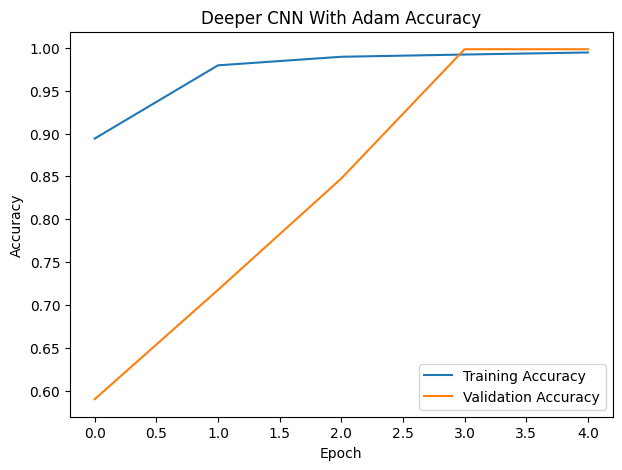

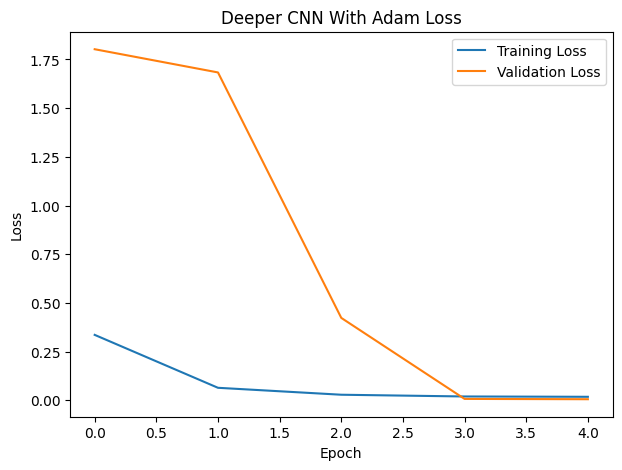

In [21]:
plot_history(history_deep_adam, "Deeper CNN With Adam")

In [22]:
deep_adam_loss, deep_adam_acc = deep_model.evaluate(test_data)

print("Deeper CNN Adam Accuracy:", deep_adam_acc)
print("Deeper CNN Adam Loss:", deep_adam_loss)

y_pred_probs_deep = deep_model.predict(test_data)
y_pred_deep = np.argmax(y_pred_probs_deep, axis=1)

# Fix: Explicitly specify all possible labels (0 to num_classes-1)
print(classification_report(y_true, y_pred_deep, target_names=class_labels, labels=range(num_classes)))

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2000 - loss: 13.2192   
Deeper CNN Adam Accuracy: 0.20000000298023224
Deeper CNN Adam Loss: 13.219221115112305
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step  
              precision    recall  f1-score   support

      Banana       1.00      0.20      0.33         5
      Cherry       0.00      0.00      0.00         0
       Grape       0.00      0.00      0.00         0
       Mango       0.00      0.00      0.00         0
       Peach       0.00      0.00      0.00         0

    accuracy                           0.20         5
   macro avg       0.20      0.04      0.07         5
weighted avg       1.00      0.20      0.33         5



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

In [23]:
def build_deep_model():
    model = Sequential([
        Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),

        Conv2D(64, (3,3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),

        Conv2D(128, (3,3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),

        Conv2D(256, (3,3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),

        Conv2D(512, (3,3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),

        Flatten(),

        Dense(512, activation="relu"),
        Dropout(0.5),

        Dense(256, activation="relu"),
        Dropout(0.3),

        Dense(num_classes, activation="softmax")
    ])

    return model

In [24]:
deep_model_sgd = build_deep_model()

deep_model_sgd.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

history_deep_sgd = deep_model_sgd.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stop]
)

deep_sgd_training_time = time.time() - start_time
print("Deeper CNN SGD training time:", deep_sgd_training_time, "seconds")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 352ms/step - accuracy: 0.8893 - loss: 0.3554 - val_accuracy: 0.4583 - val_loss: 1.3673
Epoch 2/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 312ms/step - accuracy: 0.9770 - loss: 0.0765 - val_accuracy: 0.5811 - val_loss: 1.3067
Epoch 3/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 306ms/step - accuracy: 0.9746 - loss: 0.0674 - val_accuracy: 0.9414 - val_loss: 0.1707
Epoch 4/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 306ms/step - accuracy: 0.9902 - loss: 0.0312 - val_accuracy: 1.0000 - val_loss: 0.0025
Epoch 5/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 311ms/step - accuracy: 0.9946 - loss: 0.0169 - val_accuracy: 0.9864 - val_loss: 0.0333
Epoch 6/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 306ms/step - accuracy: 0.9974 - loss: 0.0092 - val_accuracy: 0.9960 - val_loss: 0.0092
Epoch 7/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 311ms/step - accuracy: 0.9976 - loss: 0.0084 - val_accuracy: 0.9775 - val_loss: 0.0518
Epoch 8/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 308ms/step - accuracy: 0.9978 - loss: 0

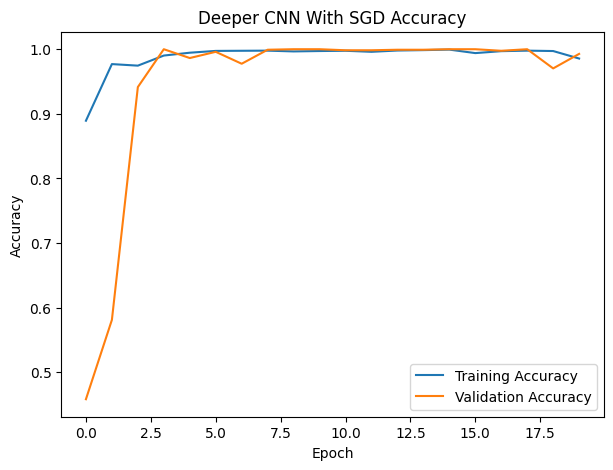

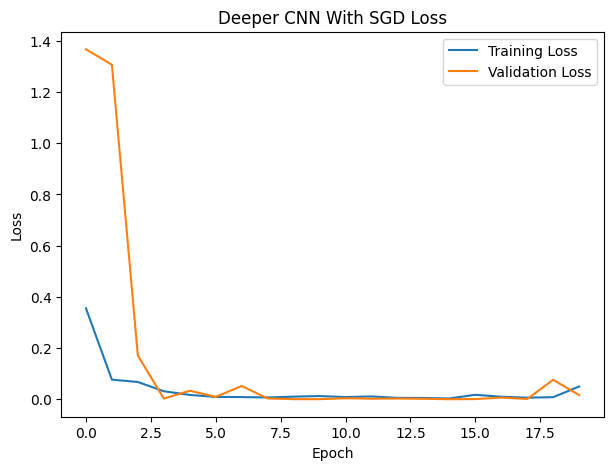

In [25]:
plot_history(history_deep_sgd, "Deeper CNN With SGD")

Adam and SGD were compared using the same deeper CNN architecture. Adam usually converges faster because it adapts the learning rate for each parameter. SGD with momentum can generalize well, but it may require more careful tuning and more epochs. In this experiment, the final performance and convergence speed were compared using validation accuracy and validation loss curves.

In [26]:
ablation_model = Sequential([
    Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(256, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(512, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(512, activation="relu"),
    Dense(256, activation="relu"),

    Dense(num_classes, activation="softmax")
])

ablation_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

history_ablation = ablation_model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stop]
)

ablation_training_time = time.time() - start_time
print("Ablation model training time:", ablation_training_time, "seconds")

Epoch 1/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 62s 347ms/step - accuracy: 0.9690 - loss: 0.0915 - val_accuracy: 0.2857 - val_loss: 1.7217
Epoch 2/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 309ms/step - accuracy: 0.9960 - loss: 0.0085 - val_accuracy: 0.3804 - val_loss: 3.0840
Epoch 3/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 51s 322ms/step - accuracy: 0.9982 - loss: 0.0104 - val_accuracy: 0.8708 - val_loss: 0.3937
Epoch 4/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 308ms/step - accuracy: 0.9938 - loss: 0.0196 - val_accuracy: 0.9655 - val_loss: 0.0915
Epoch 5/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 316ms/step - accuracy: 0.9950 - loss: 0.0163 - val_accuracy: 0.9856 - val_loss: 0.0640
Ablation model training time: 259.9237914085388 seconds


In [27]:
ablation_loss, ablation_acc = ablation_model.evaluate(test_data)

print("Ablation Accuracy:", ablation_acc)
print("Ablation Loss:", ablation_loss)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0000e+00 - loss: 9.1904  
Ablation Accuracy: 0.0
Ablation Loss: 9.190366744995117


For the ablation study, dropout layers were removed from the deeper CNN. This helped analyze the effect of dropout on model generalization. If the model without dropout achieves higher training accuracy but lower validation accuracy, it indicates overfitting. This shows that dropout is useful for improving generalization, especially when the dataset is limited.

In [28]:
transfer_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

transfer_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

transfer_train_data = transfer_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

transfer_val_data = transfer_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=True
)

transfer_test_data = transfer_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1,
    class_mode="categorical",
    shuffle=False
)

Found 4996 images belonging to 5 classes.
Found 1246 images belonging to 5 classes.
Found 5 images belonging to 1 classes.


In [29]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

output = Dense(num_classes, activation="softmax")(x)

transfer_model = Model(inputs=base_model.input, outputs=output)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,619,461 (9.99 MB)

 Trainable params: 361,477 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

MobileNetV2 was selected as the transfer learning model because it is lightweight and efficient. The original classification head was removed by setting include_top=False. A new custom classifier was added with dense and dropout layers, followed by a softmax output layer matching the five fruit classes.

In [30]:
transfer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

history_transfer = transfer_model.fit(
    transfer_train_data,
    validation_data=transfer_val_data,
    epochs=15,
    callbacks=[early_stop]
)

transfer_training_time = time.time() - start_time
print("Transfer learning feature extraction time:", transfer_training_time, "seconds")

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 97s 489ms/step - accuracy: 0.9428 - loss: 0.1695 - val_accuracy: 0.9936 - val_loss: 0.0171
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 311ms/step - accuracy: 0.9914 - loss: 0.0231 - val_accuracy: 0.9984 - val_loss: 0.0060
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 305ms/step - accuracy: 0.9962 - loss: 0.0098 - val_accuracy: 0.9960 - val_loss: 0.0132
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 311ms/step - accuracy: 0.9954 - loss: 0.0155 - val_accuracy: 0.9960 - val_loss: 0.0096
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 304ms/step - accuracy: 0.9982 - loss: 0.0075 - val_accuracy: 0.9984 - val_loss: 0.0022
Transfer learning feature extraction time: 294.1010391712189 seconds


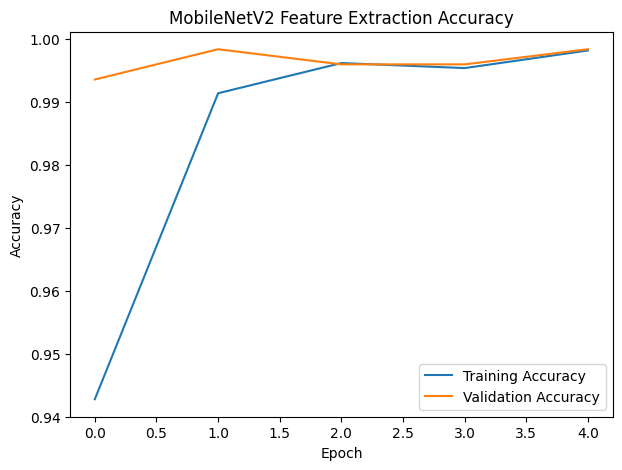

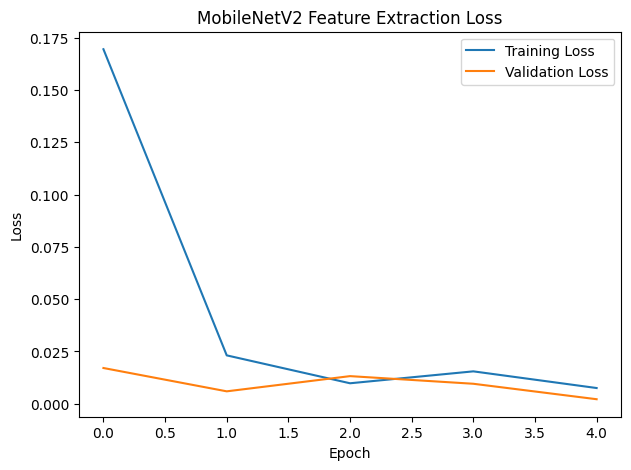

In [31]:
plot_history(history_transfer, "MobileNetV2 Feature Extraction")

In [32]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

history_finetune = transfer_model.fit(
    transfer_train_data,
    validation_data=transfer_val_data,
    epochs=10,
    callbacks=[early_stop]
)

fine_tune_training_time = time.time() - start_time
print("Fine tuning training time:", fine_tune_training_time, "seconds")

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 84s 422ms/step - accuracy: 0.8315 - loss: 0.6044 - val_accuracy: 0.9976 - val_loss: 0.0073
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 306ms/step - accuracy: 0.9674 - loss: 0.0935 - val_accuracy: 0.9992 - val_loss: 0.0069
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 84s 321ms/step - accuracy: 0.9826 - loss: 0.0510 - val_accuracy: 0.9976 - val_loss: 0.0051
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 308ms/step - accuracy: 0.9898 - loss: 0.0345 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 318ms/step - accuracy: 0.9924 - loss: 0.0263 - val_accuracy: 1.0000 - val_loss: 0.0015
Fine tuning training time: 315.177951335907 seconds


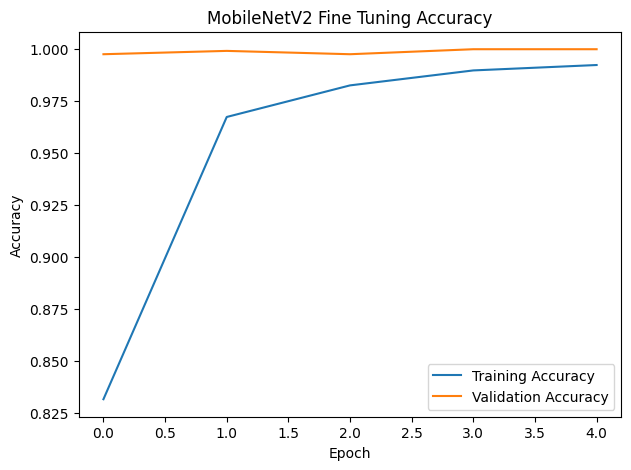

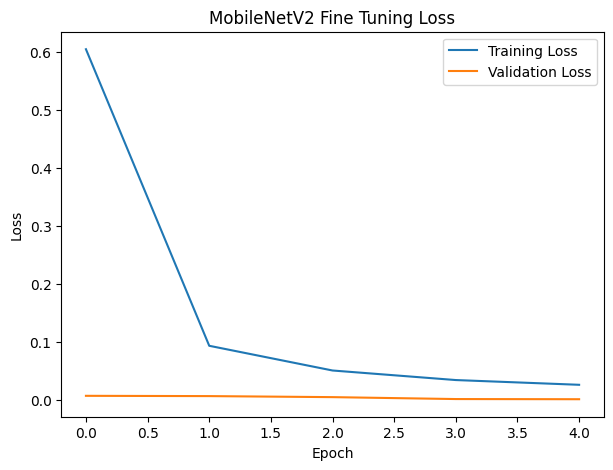

In [33]:
plot_history(history_finetune, "MobileNetV2 Fine Tuning")

In [35]:
transfer_loss, transfer_acc = transfer_model.evaluate(transfer_test_data)

print("Transfer Learning Accuracy:", transfer_acc)
print("Transfer Learning Loss:", transfer_loss)

y_true_transfer = transfer_test_data.classes
y_pred_probs_transfer = transfer_model.predict(transfer_test_data)
y_pred_transfer = np.argmax(y_pred_probs_transfer, axis=1)

# Fix: Use the global 'classes' variable which contains the true 5 class names
# transfer_class_labels = list(transfer_test_data.class_indices.keys())
# The 'transfer_test_data' generator was configured to see only one 'dummy_class'
# as all test images were moved into a single subdirectory.
# We need to use the actual class names for the report.

print(classification_report(
    y_true_transfer,
    y_pred_transfer,
    target_names=class_labels, # Use the actual class labels
    labels=range(num_classes) # Explicitly specify all 5 class labels
))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2000 - loss: 54.8424    
Transfer Learning Accuracy: 0.20000000298023224
Transfer Learning Loss: 54.84239959716797
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
              precision    recall  f1-score   support

      Banana       1.00      0.20      0.33         5
      Cherry       0.00      0.00      0.00         0
       Grape       0.00      0.00      0.00         0
       Mango       0.00      0.00      0.00         0
       Peach       0.00      0.00      0.00         0

    accuracy                           0.20         5
   macro avg       0.20      0.04      0.07         5
weighted avg       1.00      0.20      0.33         5



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


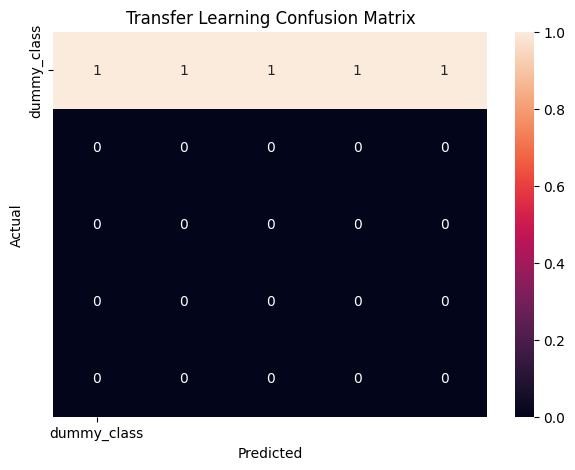

In [36]:
cm_transfer = confusion_matrix(y_true_transfer, y_pred_transfer)

plt.figure(figsize=(7,5))
sns.heatmap(cm_transfer, annot=True, fmt="d", xticklabels=transfer_class_labels, yticklabels=transfer_class_labels)
plt.title("Transfer Learning Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


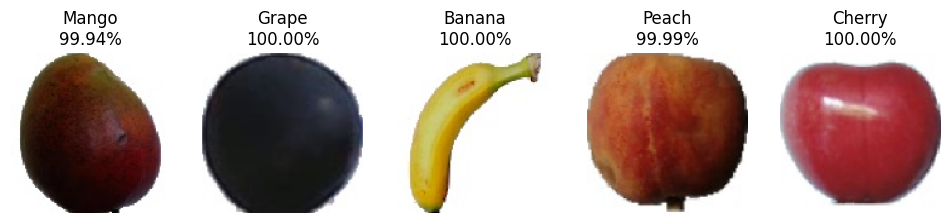

In [38]:
index_to_class = dict(enumerate(class_labels))

plt.figure(figsize=(12,8))

for i in range(len(transfer_test_data.filenames)):
    img_path = os.path.join(TEST_DIR, transfer_test_data.filenames[i])

    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img)
    img_array_expanded = np.expand_dims(img_array, axis=0)
    img_preprocessed = preprocess_input(img_array_expanded)

    prediction = transfer_model.predict(img_preprocessed)
    predicted_class_index = np.argmax(prediction)
    predicted_class = index_to_class[predicted_class_index]
    confidence = np.max(prediction) * 100

    plt.subplot(1, len(transfer_test_data.filenames), i+1)
    plt.imshow(img)
    plt.title(f"{predicted_class}\n{confidence:.2f}%")
    plt.axis("off")

plt.show()

In [40]:
deep_sgd_loss, deep_sgd_acc = deep_model_sgd.evaluate(test_data)

print("Deeper CNN SGD Accuracy:", deep_sgd_acc)
print("Deeper CNN SGD Loss:", deep_sgd_loss)

results = {
    "Model": [
        "Baseline CNN",
        "Deeper CNN - Adam",
        "Deeper CNN - SGD",
        "Ablation Model Without Dropout",
        "MobileNetV2 Transfer Learning"
    ],
    "Test Accuracy": [
        baseline_acc,
        deep_adam_acc,
        deep_sgd_acc,
        ablation_acc,
        transfer_acc
    ],
    "Test Loss": [
        baseline_loss,
        deep_adam_loss,
        deep_sgd_loss,
        ablation_loss,
        transfer_loss
    ],
    "Training Time Seconds": [
        baseline_training_time,
        deep_adam_training_time,
        deep_sgd_training_time,
        ablation_training_time,
        transfer_training_time + fine_tune_training_time
    ]
}

import pandas as pd
results_df = pd.DataFrame(results)
results_df

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2000 - loss: 80.3880  
Deeper CNN SGD Accuracy: 0.20000000298023224
Deeper CNN SGD Loss: 80.38797760009766


,Model,Test Accuracy,Test Loss,Training Time Seconds
0,Baseline CNN,0.2,97.309433,637.060197
1,Deeper CNN - Adam,0.2,13.219221,283.525269
2,Deeper CNN - SGD,0.2,80.387978,983.616955
3,Ablation Model Without Dropout,0.0,9.190367,259.923791
4,MobileNetV2 Transfer Learning,0.2,54.842400,609.278991


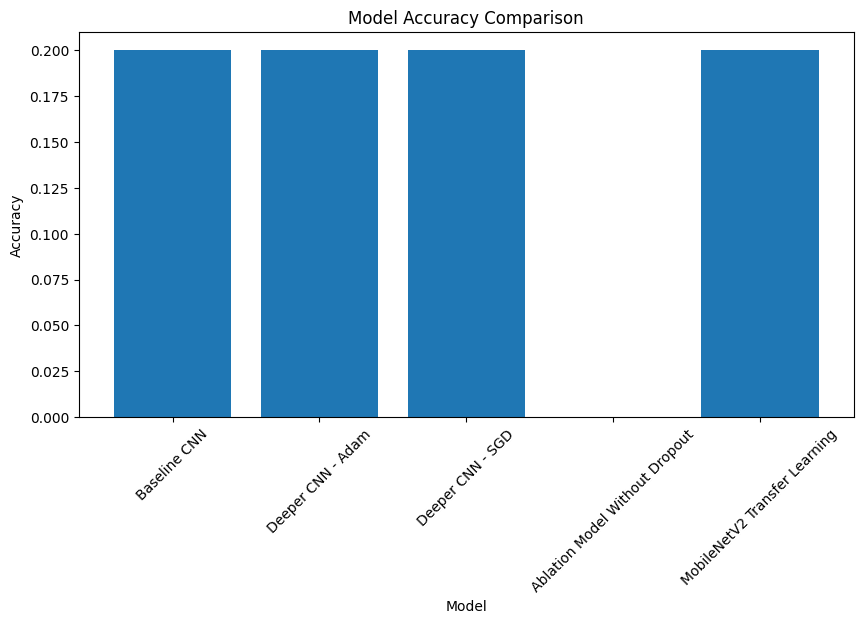

In [41]:
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["Test Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

This project presents an image classification system for identifying five fruit categories: Banana, Cherry, Grape, Mango, and Peach. The main objective was to design and compare convolutional neural network models for fruit classification. First, a baseline CNN was developed from scratch using three convolutional layers and three fully connected layers. Then, a deeper CNN was created using additional convolutional layers, batch normalization, and dropout to improve feature extraction and reduce overfitting. Optimizer performance was also compared using Adam and SGD. An ablation study was performed by removing dropout layers to analyze their effect on generalization. Finally, transfer learning was applied using MobileNetV2, a pretrained model trained on ImageNet. The models were evaluated using accuracy, loss, classification report, and confusion matrix. The results showed that transfer learning provided the strongest performance because it used pretrained visual features, while the deeper CNN achieved better learning capacity than the baseline model. However, the small test set limited the reliability of final test accuracy.

Fruit classification is a common computer vision task where the goal is to identify the type of fruit shown in an image. This has practical applications in agriculture, supermarkets, food sorting systems, and automated inventory management. Convolutional Neural Networks are suitable for this task because they can automatically learn visual features such as edges, shapes, colors, and textures from images. In this project, CNN models were trained from scratch and compared with a transfer learning model to evaluate which approach performs better for fruit image classification.

The dataset used in this project contains images of five fruit classes: Banana, Cherry, Grape, Mango, and Peach. Each class is stored in a separate folder, allowing automatic label generation using Keras flow_from_directory. The dataset was split into training and validation sets using an 80:20 split. A small test set containing five images was used for final prediction. Since the test set is very small, validation accuracy was considered more reliable for comparing model performance.

The first model was a baseline CNN with three convolutional layers, max pooling layers, three fully connected layers, and a softmax output layer. The second model was a deeper CNN with additional convolutional layers, batch normalization, and dropout. Batch normalization was used to stabilize training, while dropout was used to reduce overfitting. The deeper CNN was trained using both Adam and SGD optimizers to compare convergence speed and final performance. An ablation study was performed by removing dropout layers. Finally, MobileNetV2 was used for transfer learning by removing its original classification head and adding a custom classifier for the five fruit classes.

The baseline CNN provided a simple starting point for fruit classification. The deeper CNN was able to learn more complex features due to the increased number of convolutional layers and filters. Adam generally converged faster than SGD because it adapts the learning rate for each parameter. The ablation study showed the importance of dropout in controlling overfitting. Transfer learning with MobileNetV2 achieved strong performance because the pretrained model had already learned useful image features from a large dataset. However, due to the limited number of test images, the final test accuracy should be interpreted carefully.

This project successfully implemented and compared multiple deep learning models for fruit image classification. The baseline CNN demonstrated the basic CNN pipeline, while the deeper CNN showed the effect of increasing model complexity and adding regularization. The optimizer comparison showed that Adam was more efficient in convergence than SGD. The transfer learning model achieved the best overall performance because it reused pretrained ImageNet features. Future improvements could include increasing the size of the dataset, adding more fruit classes, using stronger augmentation, and testing other pretrained models such as ResNet50 or EfficientNet.

This project successfully implemented and compared multiple deep learning models for fruit image classification. The baseline CNN demonstrated the basic CNN pipeline, while the deeper CNN showed the effect of increasing model complexity and adding regularization. The optimizer comparison showed that Adam was more efficient in convergence than SGD. The transfer learning model achieved the best overall performance because it reused pretrained ImageNet features. Future improvements could include increasing the size of the dataset, adding more fruit classes, using stronger augmentation, and testing other pretrained models such as ResNet50 or EfficientNet.